# ロバストスペクトル推定 / Robust spectral estimation with Rényi divergence

上から順に全セルを実行してください。 / Run all cells from top to bottom.

| 手順 / Step | 内容 / Topic |
|:--|:--|
| 1 | ライブラリと設定 / Libraries and configuration |
| 2 | スペクトルモデルの設定 / Specify a spectral model |
| 3 | 時系列の生成とPSDの計算 / Simulate time series and compute PSDs |
| 4 | 目的関数とコーナー周波数の探索 / Objective functions and corner-frequency search |
| 5 | 推定曲線とパラメータの比較 / Compare fitted spectra and parameters |
| 6 | パラメトリックブートストラップ / Parametric bootstrap |

関連論文 / Related papers:

- [Takabatake & Yano (2026), On robustness of spectral Rényi divergence](https://doi.org/10.1007/s10463-026-00983-y)
- [Kano et al. (2025), Spatio-temporal characteristics in the GEONET F5 solution in the frequency domain estimated based on the robust spectral analysis](https://link.springer.com/article/10.1186/s40623-025-02236-3)

## 1. 準備と設定 / Setup and configuration


まずは設定を変えずに実行してください。`SEASONAL_SCALE = 0` にすると周期成分がなくなり、
2つの時系列・PSD・推定結果が一致します。

**English**

Start with the defaults. Setting `SEASONAL_SCALE = 0` removes the periodic components,
so the two time series, PSDs, and fitted results become identical.

In [ ]:
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import minimize
from scipy.signal import periodogram
from IPython.display import display
from scipy.integrate import quad
from scipy.optimize import brentq


plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "lines.linewidth": 2,
})
pd.set_option("display.precision", 5)
pd.set_option("display.max_columns", None)

print(f"NumPy {np.__version__} / SciPy {scipy.__version__} / pandas {pd.__version__}")

NumPy 2.1.3 / SciPy 1.16.3 / pandas 2.2.3


In [ ]:
# 時系列の設定 / Time-series settings
SEED = 42
N_SAMPLES = int(20 * 365.25)  # 20年分の日次データ / 20 years of daily samples
DT_DAYS = 1.0                 # 標本間隔 [day] / Sampling interval [day]

# 時間領域に加える周期成分 / Periodic components added in the time domain
SEASONAL_SCALE = 1.0                         # 0で無効 / Set to 0 to disable
SEASONAL_PERIODS = np.array([365.25, 182.625]) # 周期 [day] / Periods [day]
SEASONAL_AMPLITUDES = np.array([5.0, 3.0])    # 時系列の振幅 / Time-series amplitudes

# 目的関数のRenyi alpha / Renyi alpha in the objective: 0 < alpha < 1
RENYI_ALPHA = 0.1

# 固定するコーナー周波数 [cycles/day] / Fixed corner frequencies: 3 x 2 = 6 pairs
FC_LOW_GRID = (1e-4, 1e-3, 1e-2)
FC_HIGH_GRID = (0.05, 0.5)

# 最適化する4変数 / Optimized parameters: s_low, p_low, s_high, p_high
# s**2 はスペクトルの係数 / s**2 is the coefficient of each spectral component.
PARAM_BOUNDS = np.array([
    [1.0, 100.0],                  # s_low**2: 1 to 10^4
    [0.1, 4.0],                    # p_low
    [np.sqrt(0.1), np.sqrt(10.0)],  # s_high**2: 0.1 to 10
    [0.0, 1.0],                    # p_high
])

# 最適化の収束条件 / Optimization convergence settings
OPT_OPTIONS = {"ftol": 1e-10, "gtol": 1e-6, "maxiter": 1000}

assert N_SAMPLES >= 4 and DT_DAYS > 0
assert 0 < RENYI_ALPHA < 1

## 2. 低周波・高周波の2成分モデル / A two-component spectral model

$$
S(f;\theta)=
\frac{s_{\mathrm{low}}^2}{[1+(|f|/f_{c,\mathrm{low}})^{p_{\mathrm{low}}}]^2}
+\frac{s_{\mathrm{high}}^2}{[1+(|f|/f_{c,\mathrm{high}})^{p_{\mathrm{high}}}]^2}.
$$

ここでは $S(f;\theta)$ を**片側PSD**として扱います。周波数の単位は cycles/day です。
$s^2$ は成分の大きさ、$f_c$ はコーナー周波数、$p$ は形状を決めます。
パラメータの順序は `theta = [s_low, fc_low, p_low, s_high, fc_high, p_high]` です。

**English**

Here, $S(f;\theta)$ is a **one-sided PSD**, with frequency in cycles/day.
The coefficient $s^2$ sets the size of each component, $f_c$ is its corner frequency,
and $p$ controls its shape. The parameter order is
`theta = [s_low, fc_low, p_low, s_high, fc_high, p_high]`.

In [ ]:
def brune_component(frequency, amplitude, corner_frequency, slope):
    # Brune型の1成分 / One Brune-type component
    return amplitude**2 / (1 + (np.abs(frequency) / corner_frequency)**slope)**2


def mixture_psd(frequency, theta):
    # 低周波成分と高周波成分の和 / Sum of the two components
    return (brune_component(frequency, *theta[:3])
            + brune_component(frequency, *theta[3:]))

## 3. 時系列を生成し、PSDを計算する / Simulate time series and compute PSDs

1. 正規白色雑音のFourier係数に $$\sqrt{S(f)/(2\Delta t)}$$ を掛け、逆FFTで背景時系列 $x_t$ を生成します。
2. 同じ $x_t$ に正弦波を加えて、周期成分を含む系列 $y_t$ を作ります。
3. それぞれから矩形窓のピリオドグラムを計算します。平均を除去し、平滑化は行いません。

$$
y_t=x_t+c\sum_j A_j\sin(2\pi t/T_j),
\qquad c=\texttt{SEASONAL\_SCALE}.
$$

分散1の白色雑音の片側PSDは $2\Delta t$ なので、この正規化により、
推定に使うFourier周波数上で背景ピリオドグラムの**期待値**が $S(f)$ に一致します。
時系列の図には先頭5年を表示し、PSDには全期間を使います。

**English**

1. Multiply the Fourier coefficients of Gaussian white noise by $$\sqrt{S(f)/(2\Delta t)}$$,
   then apply an inverse FFT to generate the background series $x_t$.
2. Add sinusoids to the same background realization to obtain $y_t$, as defined above.
3. Compute a boxcar-window periodogram of each series, removing its mean and applying no smoothing.

Unit-variance white noise has a one-sided PSD of $2\Delta t$, so this normalization makes
the background periodogram's **expectation** equal to $S(f)$ at the Fourier frequencies used for fitting.
The time-series figure shows the first five years; PSDs use the entire record.

PSDの計算 / PSD computation:
[scipy.signal.periodogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html).

In [ ]:
def simulate_gaussian_series(n_samples, dt_days, theta, rng):
    # FFTで白色雑音を整形（周期境界） / Shape white noise with FFT (periodic boundaries)
    fft_frequency = np.fft.rfftfreq(n_samples, d=dt_days)
    gain = np.sqrt(mixture_psd(fft_frequency, theta) / (2 * dt_days))
    coefficients = np.fft.rfft(rng.standard_normal(n_samples)) * gain
    coefficients[0] = 0.0  # 平均を0に / Remove DC
    return np.fft.irfft(coefficients, n=n_samples)


def compute_psd(series, dt_days):
    frequency, density = periodogram(
        series, fs=1 / dt_days, window="boxcar", detrend="constant",
        return_onesided=True, scaling="density",
    )
    # DCと、偶数長の場合のナイキスト周波数を除く / Exclude DC and, for even lengths, Nyquist
    stop = -1 if len(series) % 2 == 0 else None
    return frequency[1:stop], density[1:stop]

def renyi_scale_factor(alpha=0.1):
    """スケール係数 c_alpha を返す。PSDの補正は 1/c_alpha 倍。
    Return c_alpha for Exp(1) periodogram noise.
    """
    if not 0 < alpha < 1:
        raise ValueError("Renyi alpha must satisfy 0 < alpha < 1.")

    def equation(c):
        return quad(
            lambda e: np.exp(-e) * (c - e)
            / (alpha * e + (1 - alpha) * c),
            0, np.inf,
        )[0]

    return brentq(equation, 1e-6, 2.0)

In [ ]:
rng = np.random.default_rng(SEED)
time_days = np.arange(N_SAMPLES) * DT_DAYS
theta_true = np.array([10.0, 1e-2, 1.5, 1.0, 0.05, 0.3])
series_clean = simulate_gaussian_series(N_SAMPLES, DT_DAYS, theta_true, rng)

seasonal = np.zeros(N_SAMPLES)
for amplitude, period in zip(SEASONAL_AMPLITUDES, SEASONAL_PERIODS):
    seasonal += amplitude * np.sin(2 * np.pi * time_days / period)
series_peaks = series_clean + SEASONAL_SCALE * seasonal

frequency, psd_clean = compute_psd(series_clean, DT_DAYS)
_, psd_peaks = compute_psd(series_peaks, DT_DAYS)
psd_true = mixture_psd(frequency, theta_true)
peak_frequencies = 1 / SEASONAL_PERIODS

print(f"標本数 / Samples: {N_SAMPLES}; 推定に使う周波数 / Fitted frequency bins: {frequency.size}")

標本数 / Samples: 7305; 推定に使う周波数 / Fitted frequency bins: 3652


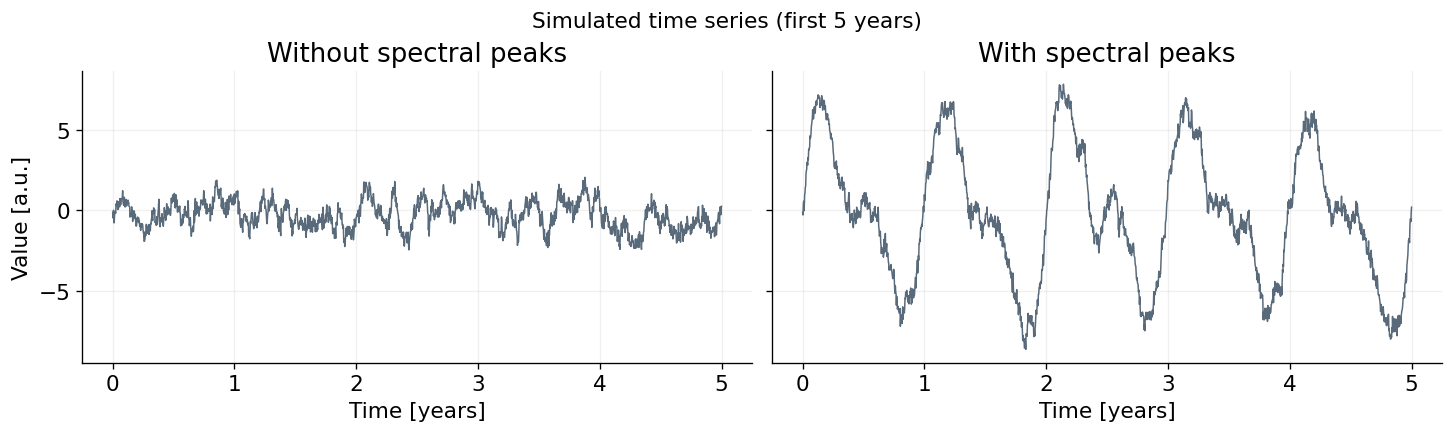

In [ ]:
visible = time_days < 5 * 365.25
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True, sharey=True,
                         layout="constrained")
for ax, series, title in zip(
    axes, [series_clean, series_peaks], ["Without spectral peaks", "With spectral peaks"]
):
    ax.plot(time_days[visible] / 365.25, series[visible], color="#596A7B", lw=0.9)
    ax.set(title=title, xlabel="Time [years]")
axes[0].set_ylabel("Value [a.u.]")
fig.suptitle("Simulated time series (first 5 years)", fontsize=13)
plt.show()

## 4. 目的関数と推定 / Objective functions and estimation

### 4.1 観測PSDとモデルのダイバージェンス / Measuring the divergence

$I_k$ を時系列から求めたPSD、$S_k$ をモデル、$m$ を使用する周波数の数とすると、目的関数は次の形です。
Renyi重みは $0<\alpha<1$ で、このデモでは $\alpha=0.1$ とします。

$$
L_\alpha (I,S)=\frac{1}{1-\alpha}\frac{1}{m}\sum_{k=1}^{m}
\left[\log\{\alpha I_k+(1-\alpha)S_k\}-\alpha\log I_k-(1-\alpha)\log S_k\right].
$$

比較用のItakura–Saito（IS）の目的関数は
$$L_{\mathrm{IS}}=\frac{1}{m}\sum_k[I_k/S_k-1-\log(I_k/S_k)]$$
です。

**English**

In $L_\alpha(I,S)$, $I_k$ is the PSD computed from the time series, $S_k$ is the model,
and $m$ is the number of frequency bins. The Renyi alpha satisfies $0<\alpha<1$; here $\alpha=0.1$.

For comparison, the Itakura–Saito (IS) objective is
$L_{\mathrm{IS}}=m^{-1}\sum_k[I_k/S_k-1-\log(I_k/S_k)]$.

In [ ]:
def spectral_renyi(observed, model, alpha=RENYI_ALPHA):
    log_ratio = np.log(observed) - np.log(model)
    log_mixture = np.logaddexp(np.log(alpha) + log_ratio, np.log1p(-alpha))
    return np.mean(log_mixture - alpha * log_ratio) / (1 - alpha)

def itakura_saito(observed, model):
    log_ratio = np.log(observed) - np.log(model)
    return np.mean(np.expm1(log_ratio) - log_ratio)

### 4.2 コーナー周波数を選ぶ / Select corner frequencies

6通りのコーナー周波数について、残る4パラメータをL-BFGS-Bで推定し、
収束した候補のうち目的関数が最小のものを選びます。

**English**

For each of the six corner-frequency pairs, fit the remaining four parameters with L-BFGS-B.
Select the converged candidate with the smallest objective.

In [ ]:
def fit_spectrum(frequency, observed, loss_function):
    if not np.all(np.isfinite(observed) & (observed > 0)):
        raise ValueError("PSDは正の有限値が必要です。 / PSD values must be positive and finite.")
    candidates = []

    for fc_low, fc_high in product(FC_LOW_GRID, FC_HIGH_GRID):
        def expand(p):
            return np.array([p[0], fc_low, p[1], p[2], fc_high, p[3]])

        def objective(p):
            return loss_function(observed, mixture_psd(frequency, expand(p)))

        initial = [np.sqrt(observed[0]) * (1 + frequency[0] / fc_low),
                   1.5, np.median(np.sqrt(observed[-100:])), 0.001]
        initial = np.clip(initial, PARAM_BOUNDS[:, 0], PARAM_BOUNDS[:, 1])
        result = minimize(objective, initial, method="L-BFGS-B",
                          bounds=PARAM_BOUNDS, options=OPT_OPTIONS)
        candidates.append({
            "theta": expand(result.x), "loss": result.fun,
            "fc_low": fc_low, "fc_high": fc_high,
            "converged": bool(result.success and np.isfinite(result.fun)
                              and np.all(np.isfinite(result.x))),
        })

    successful = [c for c in candidates if c["converged"]]
    if not successful:
        raise RuntimeError("収束した候補がありません。 / No candidate converged.")
    best = min(successful, key=lambda c: c["loss"])
    return best, candidates

## 5. 実行して比べる / Run and compare

同じ背景時系列に対して、周期成分を加えない場合と加えた場合のPSDをそれぞれ推定します。
両手法で初期値設定を共通にし、まず周期成分ありのRényi推定による6パラメータの推定結果を確認します。
周期成分を加えたとき、背景の推定曲線がどれだけ変わるかを比べてください。

**English**

Fit the PSDs of the same background realization without and with seasonal components,
using the same initialization rule for both methods. First inspect the six Rényi estimates
for the series with peaks. Compare how much the estimated background changes after adding seasonal components.

In [ ]:
datasets = {"Without spectral peaks": psd_clean, "With spectral peaks": psd_peaks}
losses = {
    "Renyi": lambda observed, model: spectral_renyi(observed, model, RENYI_ALPHA),
    "IS": itakura_saito,
}
fits = {}

for case, observed in datasets.items():
    for method, loss_function in losses.items():
        fits[case, method], candidates = fit_spectrum(frequency, observed, loss_function)
        if case == "With spectral peaks" and method == "Renyi":
            print("周期成分あり・Rényi推定の候補 / Rényi candidates with peaks (sorted by loss)")
            table = pd.DataFrame(candidates).drop(columns="theta").sort_values("loss")
            display(table.reset_index(drop=True))

周期成分あり・Rényi推定の候補 / Rényi candidates with peaks (sorted by loss)


,loss,fc_low,fc_high,converged
0,0.06058,0.0100,0.05,True
1,0.06059,0.0100,0.50,True
2,0.06099,0.0010,0.50,True
3,0.06099,0.0010,0.05,True
4,0.06314,0.0001,0.05,True
5,0.06314,0.0001,0.50,True


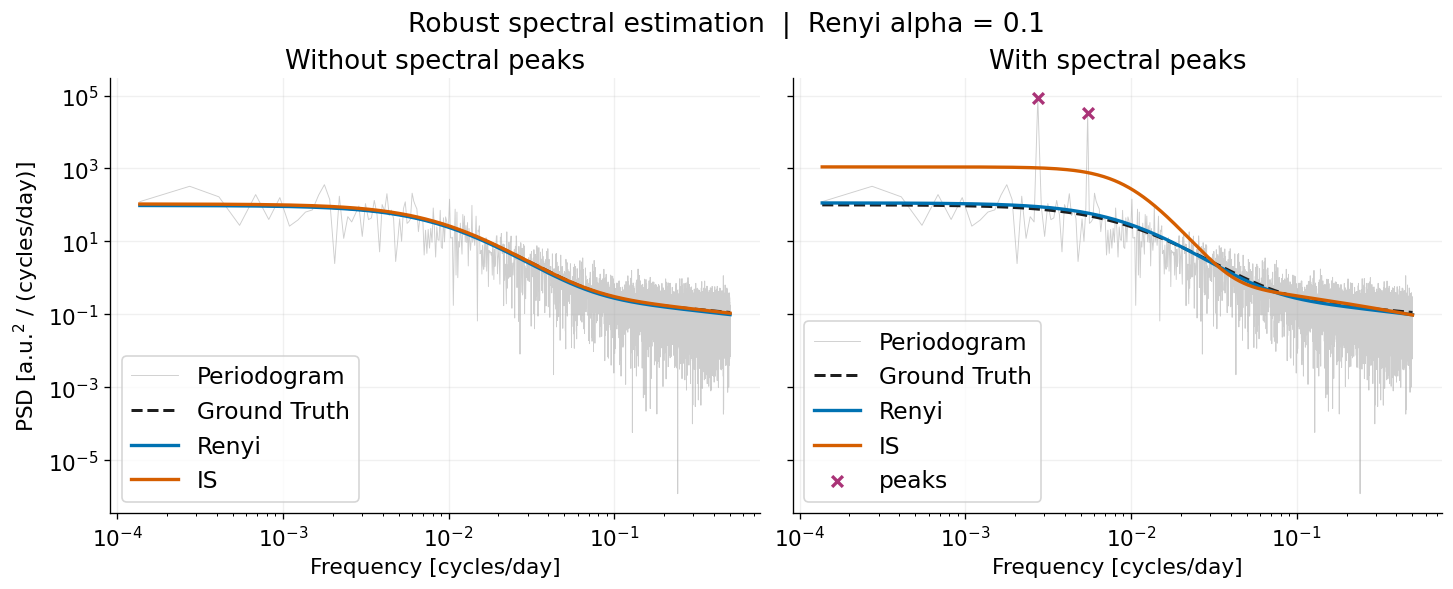

In [ ]:
colors = {"Renyi": "#0072B2", "IS": "#D55E00"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True,
                         layout="constrained")

for ax, (case, observed) in zip(axes, datasets.items()):
    ax.loglog(frequency, observed, color="0.65", lw=0.55, alpha=0.55,
              label="Periodogram")
    ax.loglog(frequency, psd_true, color="0.12", ls="--", lw=1.8,
              label="Ground Truth")
    for method in losses:
        fitted = mixture_psd(frequency, fits[case, method]["theta"])
        ax.loglog(frequency, fitted, color=colors[method], label=method)
    if case == "With spectral peaks" and SEASONAL_SCALE > 0:
        peak_indices = [np.argmin(np.abs(frequency - f)) for f in peak_frequencies]
        ax.scatter(frequency[peak_indices], observed[peak_indices], s=42, marker="x",
                   color="#AA3377", zorder=5, label="peaks")
    ax.set(title=case, xlabel="Frequency [cycles/day]")
    ax.legend(fontsize=14, loc="lower left")

axes[0].set_ylabel("PSD [a.u.$^2$ / (cycles/day)]")
fig.suptitle(f"Robust spectral estimation  |  Renyi alpha = {RENYI_ALPHA:g}",
             fontsize=16)
plt.show()

In [ ]:
def parameter_row(theta):
    s_low, fc_low, p_low, s_high, fc_high, p_high = theta
    return {
        "s_low^2": s_low**2, "fc_low": fc_low, "p_low": p_low,
        "s_high^2": s_high**2, "fc_high": fc_high, "p_high": p_high,
    }


rows = [{"case": "Reference", "method": "True", **parameter_row(theta_true),
         "log_RMSE": 0.0}]

for (case, method), result in fits.items():
    fitted = mixture_psd(frequency, result["theta"])
    log_rmse = np.sqrt(np.mean((np.log(fitted) - np.log(psd_true))**2))
    rows.append({"case": case, "method": method, **parameter_row(result["theta"]),
                 "log_RMSE": log_rmse})

summary = pd.DataFrame(rows).set_index(["case", "method"])
display(summary)

s_low^2  fc_low    p_low  s_high^2  fc_high  \
case                   method                                                   
Reference              True     100.00000    0.01  1.50000   1.00000     0.05   
Without spectral peaks Renyi     95.79612    0.01  1.53862   1.04966     0.05   
                       IS       105.22961    0.01  1.53837   1.16004     0.05   
With spectral peaks    Renyi    112.61043    0.01  1.61375   1.11850     0.05   
                       IS      1102.08772    0.01  2.69957   1.90316     0.05   

                                p_high  log_RMSE  
case                   method                     
Reference              True    0.30000   0.00000  
Without spectral peaks Renyi   0.35764   0.09070  
                       IS      0.36137   0.02826  
With spectral peaks    Renyi   0.37988   0.09467  
                       IS      0.53879   0.46664

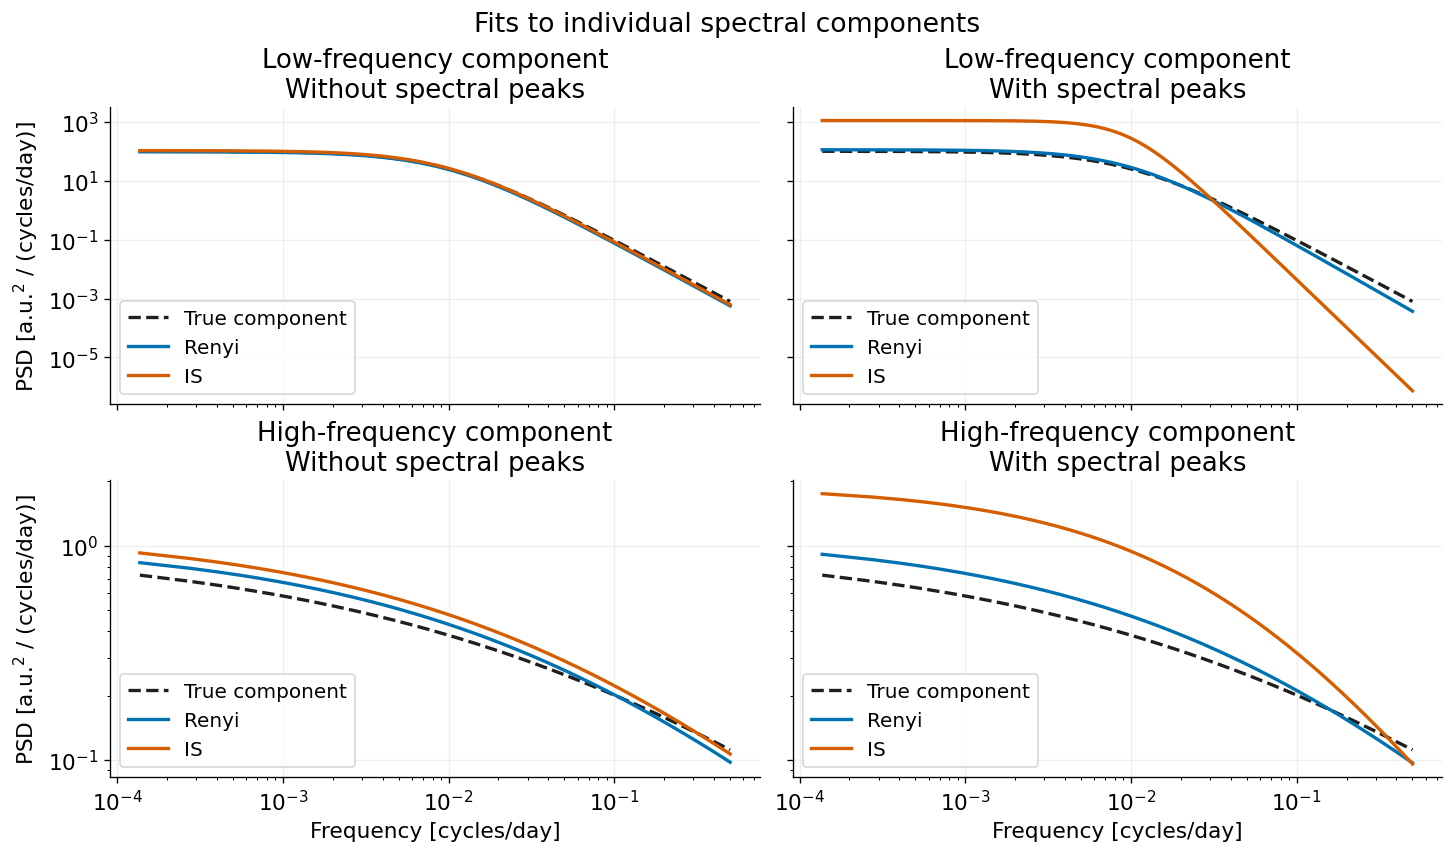

In [ ]:
# 各成分の推定を比較 / Compare the fitted components
components = [("Low-frequency component", slice(0, 3)),
              ("High-frequency component", slice(3, 6))]
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey="row",
                         layout="constrained")

for row, (name, indices) in enumerate(components):
    for col, case in enumerate(datasets):
        ax = axes[row, col]
        ax.loglog(frequency, brune_component(frequency, *theta_true[indices]),
                  color="0.12", ls="--", label="True component")
        for method in losses:
            theta_hat = fits[case, method]["theta"]
            ax.loglog(frequency, brune_component(frequency, *theta_hat[indices]),
                      color=colors[method], label=method)
        ax.set_title(f"{name}\n{case}")
        ax.legend(fontsize=12, loc="lower left")
        if col == 0:
            ax.set_ylabel("PSD [a.u.$^2$ / (cycles/day)]")
        if row == 1:
            ax.set_xlabel("Frequency [cycles/day]")

fig.suptitle("Fits to individual spectral components", fontsize=16)
plt.show()

## 6. パラメトリックブートストラップ / Parametric bootstrap

各ケース・各手法について、当てはめたスペクトルから
$I_k^*=\widehat S_k E_k$（$E_k$ は互いに独立な平均1の指数乱数）を生成し、推定を繰り返します。

帯は、各周波数におけるブートストラップ推定曲線の2.5–97.5%分位点を示します。
`BOOTSTRAP_SIZE` の初期値40回はデモ用です。端の分位点を安定させるには反復数を増やします。

**注意：** パラメトリックブートストラップでは、区間推定に影響するRényi推定のスケールバイアスを補正するため、`renyi_scale_factor` 関数を用います。


**English**

For each case and method, draw $I_k^*=\widehat S_k E_k$, with independent mean-one
exponential draws $E_k$, and refit.

The shaded area shows the pointwise 2.5th–97.5th percentiles of the bootstrap fitted spectra.
The default `BOOTSTRAP_SIZE = 20` is for a quick demo; use more replicates for stable tail quantiles.

**Note:** In the parametric bootstrap, we use `renyi_scale_factor` to correct for the scale bias in Rényi estimates when constructing confidence intervals.


In [ ]:
BOOTSTRAP_SIZE = 40  # デモ用 / Demo replicate count
BOOTSTRAP_SEED = SEED + 1
CI_LEVEL = 0.95
assert BOOTSTRAP_SIZE >= 2 and 0 < CI_LEVEL < 1

rng_boot = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap_thetas = {}
scale_biascorrected = 1/renyi_scale_factor(RENYI_ALPHA)

for (case, method), result in fits.items():
    fitted = mixture_psd(frequency, result["theta"])
    thetas = []
    for _ in range(BOOTSTRAP_SIZE):
        psd_boot = rng_boot.exponential(scale=fitted * (scale_biascorrected if method == "Renyi" else 1.0))
        boot_fit, _ = fit_spectrum(frequency, psd_boot, losses[method])
        thetas.append(boot_fit["theta"])
    bootstrap_thetas[case, method] = np.array(thetas)
    print(f"{case} / {method}: {len(thetas)} replicates")

Without spectral peaks / Renyi: 40 replicates
Without spectral peaks / IS: 40 replicates
With spectral peaks / Renyi: 40 replicates
With spectral peaks / IS: 40 replicates


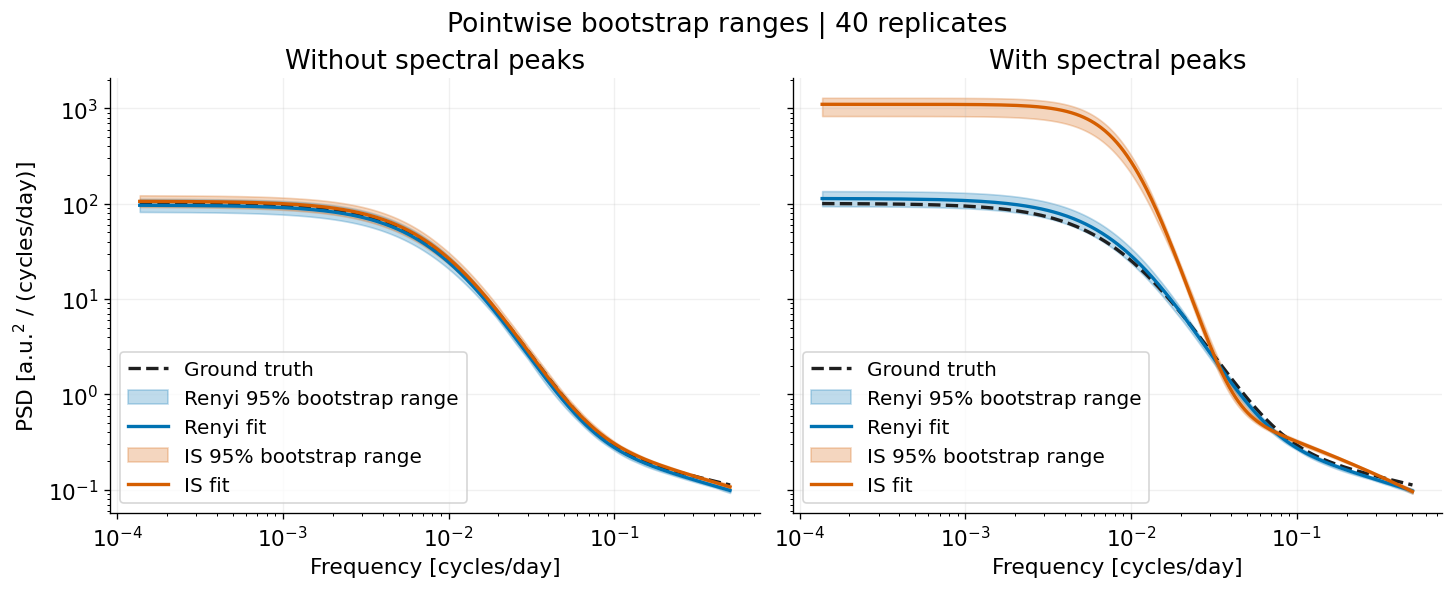

In [ ]:
q = (1 - CI_LEVEL) / 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True,
                         layout="constrained")

for ax, case in zip(axes, datasets):
    ax.loglog(frequency, psd_true, color="0.12", ls="--", label="Ground truth")
    for method in losses:
        fitted = mixture_psd(frequency, fits[case, method]["theta"])
        spectra = [mixture_psd(frequency, theta) for theta in bootstrap_thetas[case, method]]
        lower, upper = np.quantile(spectra, [q, 1 - q], axis=0)
        ax.fill_between(frequency, lower, upper, color=colors[method], alpha=0.25,
                         label=f"{method} {CI_LEVEL:.0%} bootstrap range")
        ax.loglog(frequency, fitted, color=colors[method], label=f"{method} fit")
    ax.set(title=case, xlabel="Frequency [cycles/day]")
    ax.legend(fontsize=12, loc="lower left")

axes[0].set_ylabel("PSD [a.u.$^2$ / (cycles/day)]")
fig.suptitle(f"Pointwise bootstrap ranges | {BOOTSTRAP_SIZE} replicates", fontsize=16)
plt.show()

### 各成分の比較 / Component comparison

同じブートストラップ推定から低周波・高周波の各成分を計算し、
周波数ごとの2.5–97.5%分位点を表示します。

Use the same bootstrap fits to compute the low- and high-frequency components
and show their pointwise 2.5th–97.5th percentile intervals.

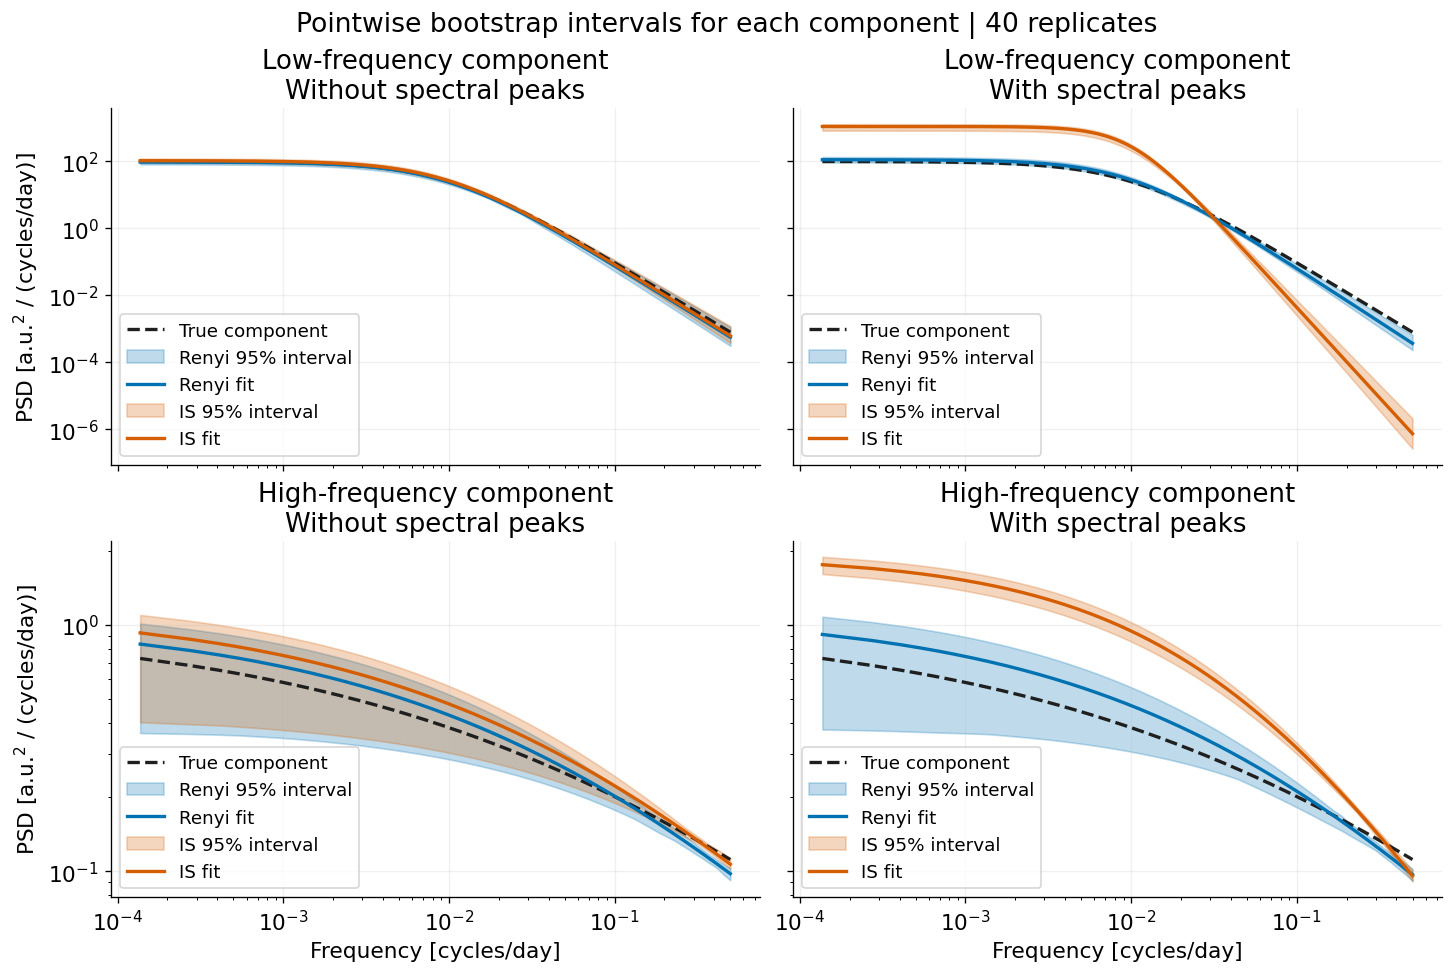

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey="row",
                         layout="constrained")

for row, (name, indices) in enumerate(components):
    for col, case in enumerate(datasets):
        ax = axes[row, col]
        ax.loglog(frequency, brune_component(frequency, *theta_true[indices]),
                  color="0.12", ls="--", label="True component")
        for method in losses:
            spectra = [brune_component(frequency, *theta[indices])
                       for theta in bootstrap_thetas[case, method]]
            lower, upper = np.quantile(spectra, [q, 1 - q], axis=0)
            ax.fill_between(frequency, lower, upper, color=colors[method], alpha=0.25,
                            label=f"{method} {CI_LEVEL:.0%} interval")
            theta_hat = fits[case, method]["theta"]
            ax.loglog(frequency, brune_component(frequency, *theta_hat[indices]),
                      color=colors[method], label=f"{method} fit")
        ax.set_title(f"{name}\n{case}")
        ax.legend(fontsize=11, loc="lower left")
        if col == 0:
            ax.set_ylabel("PSD [a.u.$^2$ / (cycles/day)]")
        if row == 1:
            ax.set_xlabel("Frequency [cycles/day]")

fig.suptitle(f"Pointwise bootstrap intervals for each component | {BOOTSTRAP_SIZE} replicates",
             fontsize=16)
plt.show()